# ***Laboratório 4.A - Filtragem de Imagens (Filtros Passa-baixa)***

## **Integrantes**
- Matheus Foresto Moselli
- Marcos Vinicius Medeiros da Silva
- Karl Eloy Marques Henrique

**Data do experimento:** 10/03/2026 <br/>
**Data de publicação do relatório:** 13/03/2026

## **Introdução**

Nesse laboratório iremos estudar os filtros **passa-baixa.** <br />
Esse tipo de filtro é utilizado para suavizar transições brutas de intensidades em imagens resultando em um efeito de *blur* (borrão).

Os filtros passa-baixa atuam reduzindo as **altas frequências espaciais** da imagem, que geralmente estão associadas a ruídos, detalhes muito finos e mudanças abruptas entre pixels vizinhos. Ao preservar principalmente as **baixas frequências**, esses filtros mantêm as estruturas mais suaves e gerais da imagem.

Filtros passa-baixa são muito utilizados para tarefas como **redução de ruído**, suavização de texturas e preparação da imagem para outras etapas de processamento, como detecção de bordas ou segmentação.

## **Procedimentos Experimentais**

*1) Nesta etapa, utilize suas próprias imagens obtidas no Lab3 - imagem dos membros juntos do grupo e imagem dos avatar juntos.*

*(a) Elabore um programa que realize as filtragens (com os filtros de média, gaussiano, mediana, e bilateral) na sua imagem com um kernel 3x3, 5x5, 11x11, e 29x29 e salve as imagens resultantes de cada filtragem, em formato .jpg.*

### **Filtro de média**

Esse filtro consiste em substituir o valor de intensidade de cada pixel pela media aritmética dos valores dos pixels na sua vizinhança. O tamanho da vizinhança é definido pelo kernel.

Nesse exemplos, aplicamos o filtro utilizando vizinhanças com 4 tamanhos diferentes:
- 3x3 (px)
- 5x5 (px)
- 11x11 (px)
- 29x29 (px)

Esse tipo de filtro é muito utilizado para reduzir ruídos na imagem. Como consequência do processo de suavização, ocorre também uma redução dos detalhes e um borramento das bordas.

A fórmula para aplicação desse filtro é a seguinte: <br />

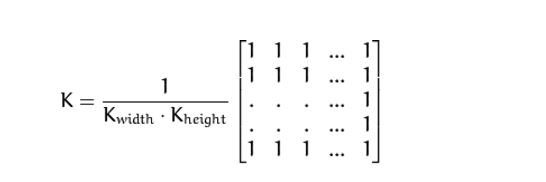


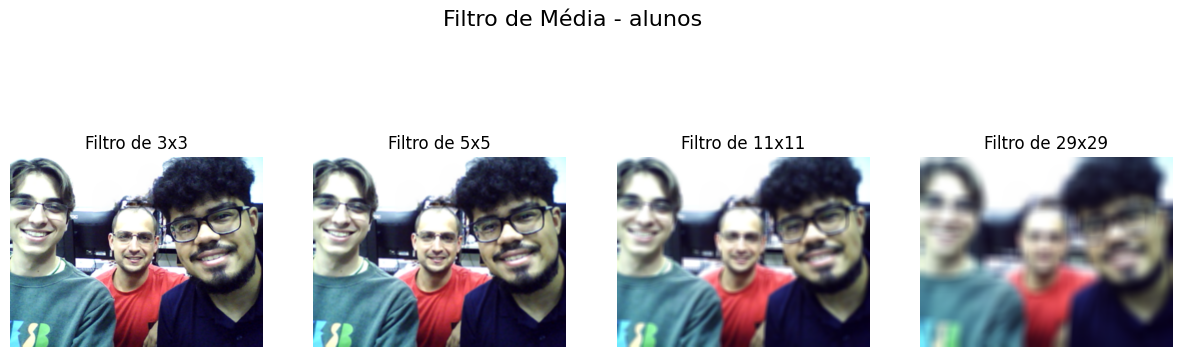

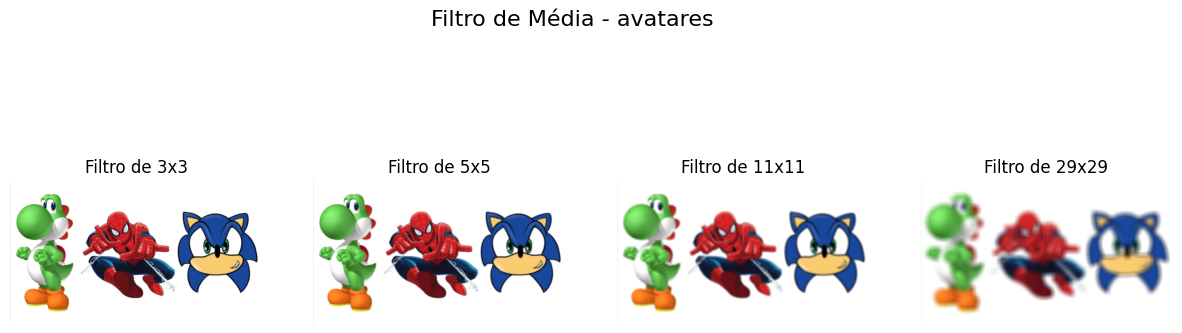

In [1]:
# Filtro de média - Homogeneous Blur
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

#  Global Variables

KERNELS = [3, 5, 11, 29]
arquivos = ["alunos", "avatares"]
src = "img"
dst = "filtros"

def homogeneous_blur(src_img, dst_img, title):
    for i in range(0, len(KERNELS)):
        kernel_size = KERNELS[i]
        dst_img = cv.blur(src_img, (kernel_size, kernel_size))

        dst_file_name = f"{dst}/media/{title}/{kernel_size}x{kernel_size}.jpg"
        cv.imwrite(dst_file_name, cv.cvtColor(dst_img, cv.COLOR_BGR2RGB))

        plt.subplot(1,len(KERNELS),i+1)
        plt.imshow(dst_img)
        plt.title(f'Filtro de {kernel_size}x{kernel_size}')
        plt.axis('off')

for file in arquivos:
    # Load the source image
    image_name = f'{src}/{file}.png'

    cv_src_file = cv.imread(image_name)
    cv_src_file = cv.cvtColor(cv_src_file, cv.COLOR_BGR2RGB)
    
    cv_dst_file = np.copy(cv_src_file)

    plt.figure(figsize=(15,5))
    
    plt.suptitle(f"Filtro de Média - {file}", fontsize=16)
    
    homogeneous_blur(cv_src_file, cv_dst_file, file)
    
    plt.show()

### **Filtro gaussiano**

Esse filtro consiste em substituir o valor de intensidade de cada pixel por uma média ponderada dos valores dos pixels na sua vizinhança. Diferente do filtro de média simples, os pixels mais próximos do centro recebem maior peso, enquanto os mais distantes recebem pesos menores, seguindo uma distribuição gaussiana. O tamanho da vizinhança é definido pelo kernel.

Nesse exemplo, aplicamos o filtro utilizando vizinhanças com 4 tamanhos diferentes:

- 3x3 (px)
- 5x5 (px)
- 11x11 (px)
- 29x29 (px)

Esse tipo de filtro é muito utilizado para reduzir ruídos e realizar suavização da imagem, preservando melhor as estruturas importantes quando comparado ao filtro de média. Como consequência, ocorre uma redução de detalhes finos e suavização das bordas.

A fórmula para aplicação desse filtro é a seguinte: <br />

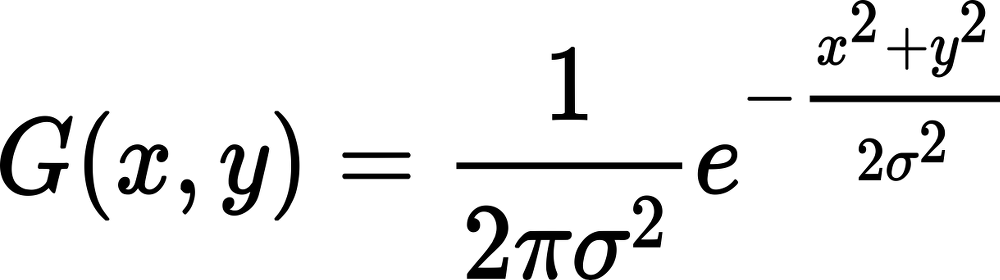

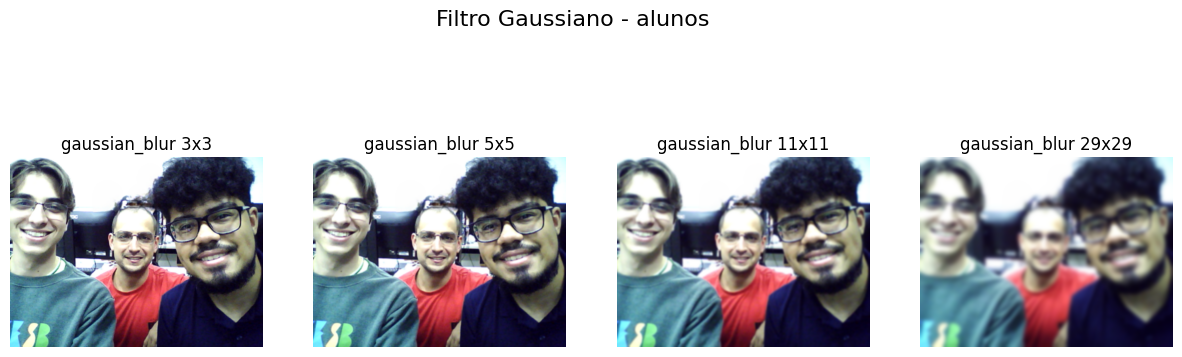

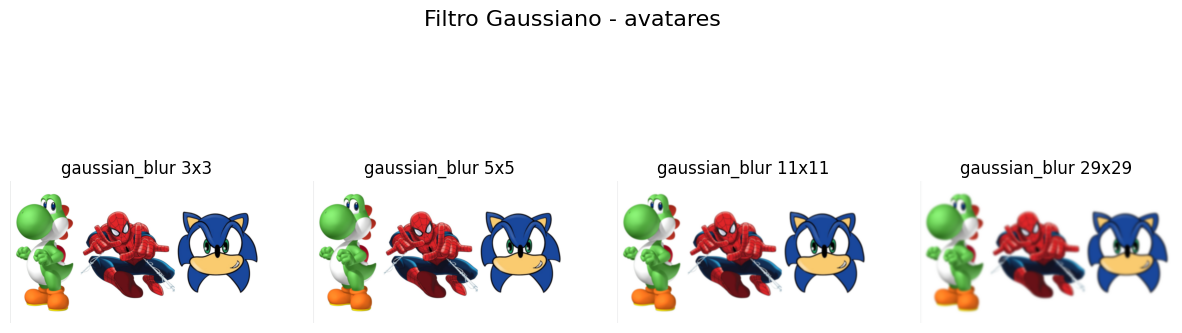

In [2]:
# Filtro gaussiano - Gaussian Blur
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

#  Global Variables

KERNELS = [3, 5, 11, 29]
arquivos = ["alunos", "avatares"]
src = "img"
dst = "filtros"

def gaussian_blur(src_img, dst_img, title):
    for i in range(0, len(KERNELS)):
        kernel_size = KERNELS[i]
        dst_img = cv.GaussianBlur(src_img, (kernel_size, kernel_size), 0)

        dst_file_name = f"{dst}/gaussiana/{title}/{kernel_size}x{kernel_size}.jpg"
        cv.imwrite(dst_file_name, cv.cvtColor(dst_img, cv.COLOR_BGR2RGB))

        plt.subplot(1,len(KERNELS),i+1)
        plt.imshow(dst_img)
        plt.title(f'gaussian_blur {kernel_size}x{kernel_size}')
        plt.axis('off')

for file in arquivos:
    # Load the source image
    image_name = f'{src}/{file}.png'

    cv_src_file = cv.imread(image_name)
    cv_src_file = cv.cvtColor(cv_src_file, cv.COLOR_BGR2RGB)
    
    cv_dst_file = np.copy(cv_src_file)

    plt.figure(figsize=(15,5))
    
    plt.suptitle(f"Filtro Gaussiano - {file}", fontsize=16)
    
    gaussian_blur(cv_src_file, cv_dst_file, file)
    
    plt.show()

### **Filtro da mediana**

Esse filtro consiste em substituir o valor de intensidade de cada pixel pelo valor da mediana dos pixels presentes na sua vizinhança. Para isso, todos os valores de intensidade dentro do kernel são ordenados e o valor central dessa ordenação é utilizado como novo valor para o pixel analisado. O tamanho da vizinhança é definido pelo kernel.

Nesse exemplo, aplicamos o filtro utilizando vizinhanças com 4 tamanhos diferentes:

- 3x3 (px)
- 5x5 (px)
- 11x11 (px)
- 29x29 (px)

Esse tipo de filtro é muito utilizado para reduzir ruídos do tipo sal-e-pimenta, pois valores extremos (muito altos ou muito baixos) têm pouca influência no resultado da mediana. Como consequência, o filtro consegue remover ruídos preservando melhor as bordas da imagem quando comparado a filtros baseados em média.

Um exemplo da aplicação desse filtro: <br />

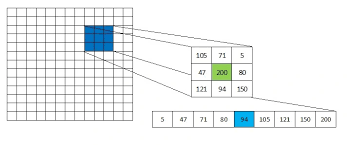

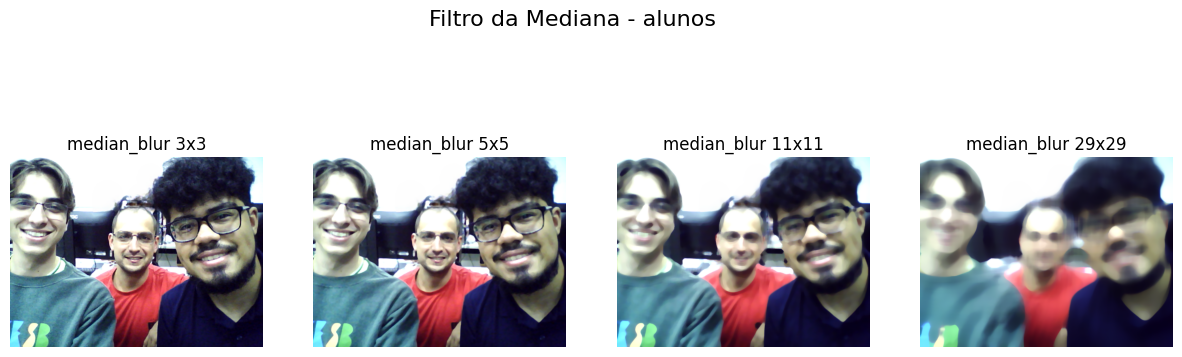

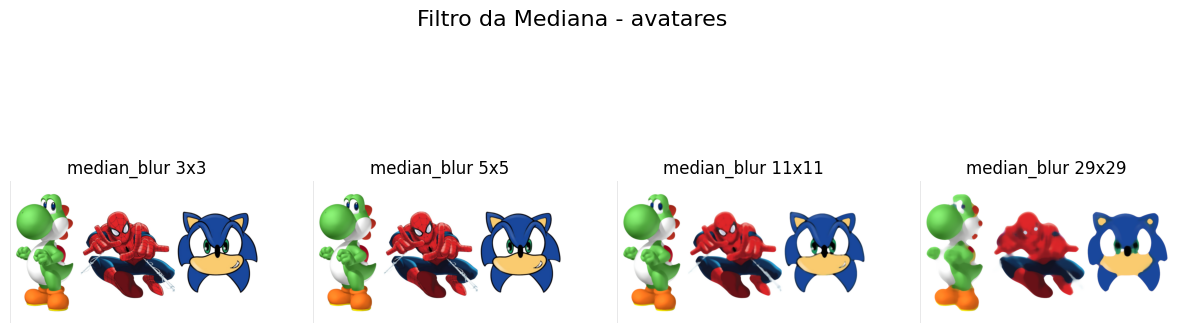

In [3]:
# Filtro de mediana - Median Blur
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

#  Global Variables

KERNELS = [3, 5, 11, 29]
arquivos = ["alunos", "avatares"]
src = "img"
dst = "filtros"

def median_blur(src_img, dst_img, title):
    for i in range(0, len(KERNELS)):
        kernel_size = KERNELS[i]
        dst_img = cv.medianBlur(src_img, kernel_size)

        dst_file_name = f"{dst}/mediana/{title}/{kernel_size}x{kernel_size}.jpg"
        cv.imwrite(dst_file_name, cv.cvtColor(dst_img, cv.COLOR_BGR2RGB))

        plt.subplot(1,len(KERNELS),i+1)
        plt.imshow(dst_img)
        plt.title(f'median_blur {kernel_size}x{kernel_size}')
        plt.axis('off')

for file in arquivos:
    # Load the source image
    image_name = f'{src}/{file}.png'

    cv_src_file = cv.imread(image_name)
    cv_src_file = cv.cvtColor(cv_src_file, cv.COLOR_BGR2RGB)
    
    cv_dst_file = np.copy(cv_src_file)

    plt.figure(figsize=(15,5))
    
    plt.suptitle(f"Filtro da Mediana - {file}", fontsize=16)
    
    median_blur(cv_src_file, cv_dst_file, file)
    
    plt.show()

### **Filtro bilateral**

Esse filtro consiste em substituir o valor de intensidade de cada pixel por uma média ponderada dos valores dos pixels na sua vizinhança, levando em consideração dois fatores: a distância espacial entre os pixels e a diferença de intensidade entre eles. Pixels próximos e com valores de intensidade semelhantes recebem pesos maiores, enquanto pixels distantes ou muito diferentes em intensidade recebem pesos menores. O tamanho da vizinhança é definido pelo kernel.

Nesse exemplo, aplicamos o filtro utilizando vizinhanças com 4 tamanhos diferentes:

- 3x3 (px)
- 5x5 (px)
- 11x11 (px)
- 29x29 (px)

Esse tipo de filtro é muito utilizado para realizar suavização da imagem enquanto preserva as bordas, pois a diferença de intensidade entre pixels faz com que regiões com mudanças bruscas (bordas) tenham menor influência no cálculo da média. Como consequência, o filtro reduz ruídos sem borrar significativamente as bordas da imagem.

A fórmula para aplicação desse filtro é a seguinte: <br />

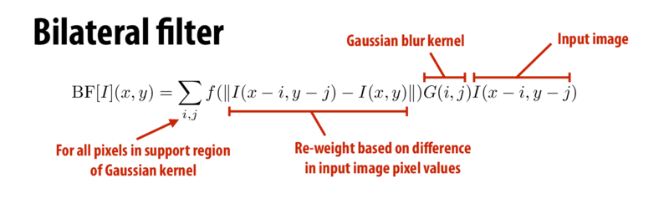

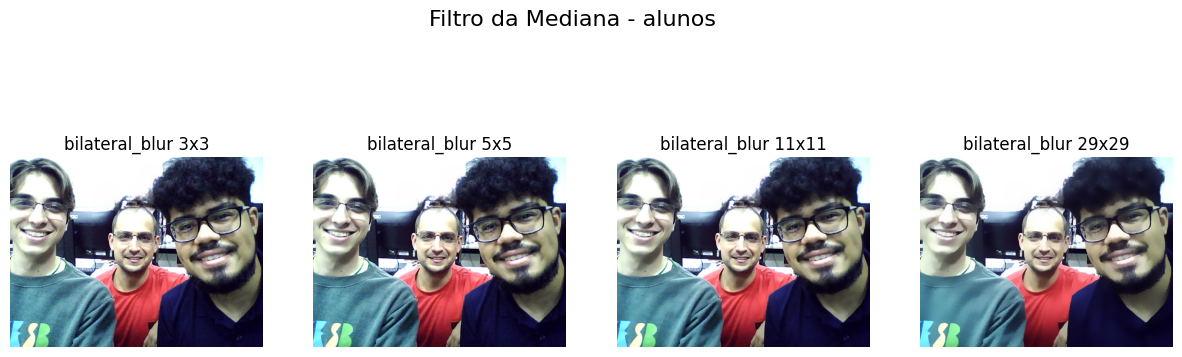

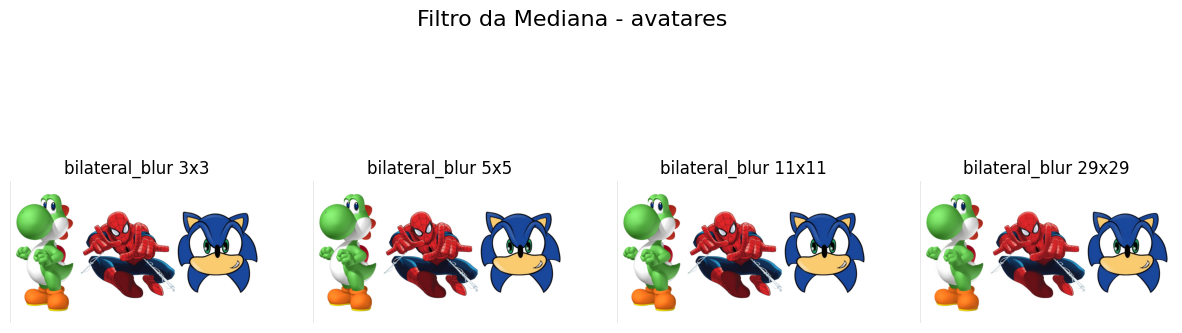

In [4]:
# Filtro bilateral - Bilateral Blur
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

#  Global Variables

KERNELS = [3, 5, 11, 29]
arquivos = ["alunos", "avatares"]
src = "img"
dst = "filtros"

def bilateral_blur(src_img, dst_img, title):
    for i in range(0, len(KERNELS)):
        kernel_size = KERNELS[i]
        dst_img = cv.bilateralFilter(src_img, kernel_size, kernel_size * 2, kernel_size / 2)

        dst_file_name = f"{dst}/bilateral/{title}/{kernel_size}x{kernel_size}.jpg"
        cv.imwrite(dst_file_name, cv.cvtColor(dst_img, cv.COLOR_BGR2RGB))

        plt.subplot(1,len(KERNELS),i+1)
        plt.imshow(dst_img)
        plt.title(f'bilateral_blur {kernel_size}x{kernel_size}')
        plt.axis('off')

for file in arquivos:
    # Load the source image
    image_name = f'{src}/{file}.png'

    cv_src_file = cv.imread(image_name)
    cv_src_file = cv.cvtColor(cv_src_file, cv.COLOR_BGR2RGB)
    
    cv_dst_file = np.copy(cv_src_file)

    
    plt.figure(figsize=(15,5))
    
    plt.suptitle(f"Filtro da Mediana - {file}", fontsize=16)
    
    bilateral_blur(cv_src_file, cv_dst_file, file)
    
    plt.show()

## **Conclusões**

## **Referências**

- MINICHINO, J.; HOWSE, J. **Learning OpenCV 3 Computer Vision with Python. 2**. ed. [S.l.]: Packt Publishing, 2015.
- OPENCV. **Flags used for image file reading and writing**. Versão 3.4.20-dev. Disponível em: https://docs.opencv.org/3.4/d8/d6a/group__imgcodecs__flags.html. Acesso em: 20 fev. 2026.
- OPENCV. **Getting Started with Images**. Disponível em: https://docs.opencv.org/4.x/db/deb/tutorial_display_image.html. Acesso em: 21 fev. 2026.
- OPENCV. **Getting Started with Videos**. Disponível em: https://docs.opencv.org/4.x/dd/d43/tutorial_py_video_display.html. Acesso em: 21 fev. 2026.
- OPENCV. **OpenCV-Python Tutorials**. Disponível em: https://docs.opencv.org/master/d6/d00/tutorial_py_root.html. Acesso em: 20 fev. 2026.
- OPENCV. **Smoothing Images**. Disponível em: https://docs.opencv.org/4.x/dc/dd3/tutorial_gausian_median_blur_bilateral_filter.html. Acesso em: 10 mar. 2026.